In [47]:
!git clone https://github.com/blessthef4llen/Parking-Space-Detection.git

Cloning into 'Parking-Space-Detection'...
remote: Enumerating objects: 1025, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 1025 (delta 17), reused 9 (delta 3), pack-reused 989 (from 2)
Receiving objects: 100% (1025/1025), 46.01 MiB | 11.98 MiB/s, done.
Resolving deltas: 100% (44/44), done.


In [48]:
%cd Parking-Space-Detection/


/content/Parking-Space-Detection/Parking-Space-Detection/Parking-Space-Detection/Parking-Space-Detection/Parking-Space-Detection


In [49]:
import os

BASE_DIR = "."
CROPS_DIR = os.path.join(BASE_DIR, "data", "crops")

print(f"BASE_DIR: {BASE_DIR}")
print(f"CROPS_DIR: {CROPS_DIR}")
print(f"Crops dir exists: {os.path.isdir(CROPS_DIR)}")

BASE_DIR: .
CROPS_DIR: ./data/crops
Crops dir exists: True


In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [51]:
import random, numpy as np, torch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [53]:
img_size = 224

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_transfrom = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

full_dataset = datasets.ImageFolder(root=CROPS_DIR, transform=train_transform)
class_names = full_dataset.classes
print(f"Classes: {class_names}")
print(f"Total samples: {len(full_dataset)}")

val_ratio = 0.2
val_size = int(len(full_dataset)*val_ratio)
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transfrom

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")

Classes: ['free_parking_space', 'not_free_parking_space', 'partially_free_parking_space']
Total samples: 903
Train samples: 723
Validation samples: 180


In [54]:
class ParkingSpacesCNN(nn.Module):
  def __init__(self, num_classes=3):
    super().__init__()

    self.conv1 = nn.Conv2d(3,32,3)
    self.pool = nn.MaxPool2d(2,2)
    self.conv2 = nn.Conv2d(32, 64, 3)
    self.conv3 = nn.Conv2d(64, 128, 3)


    self.fc1 = nn.Linear(128*26*26, 256)
    self.fc2 = nn.Linear(256, num_classes)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = self.pool(F.relu(self.conv3(x)))
    x = x.view(x.size(0), -1)
    x = F.relu(self.fc1(x))
    x = self.fc2(x)
    return x
model = ParkingSpacesCNN(num_classes=len(class_names)).to(device)
print(model)

ParkingSpacesCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=86528, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=3, bias=True)
)


In [55]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_loss = []
val_accuracies = []


In [56]:
for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

  model.eval()
  correct = 0
  total = 0

  with torch.no_grad():
    for images, labels in val_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      _, prediction = torch.max(outputs, 1)

      total += labels.size(0)
      correct += (prediction == labels).sum().item()

  epoch_loss = running_loss/ len(train_loader)
  epoch_accuracy = correct/total

  train_loss.append(epoch_loss)
  val_accuracies.append(epoch_accuracy)
  print(f"Epoch [{epoch + 1}/{num_epochs}]")
  print(f"Training Loss: {epoch_loss:.4f}, Val Acc: {epoch_accuracy:.4f}")

Epoch [1/10]
Training Loss: 0.5252, Val Acc: 0.8889
Epoch [2/10]
Training Loss: 0.1526, Val Acc: 0.9778
Epoch [3/10]
Training Loss: 0.1443, Val Acc: 0.9722
Epoch [4/10]
Training Loss: 0.0844, Val Acc: 0.9722
Epoch [5/10]
Training Loss: 0.0735, Val Acc: 0.9556
Epoch [6/10]
Training Loss: 0.0650, Val Acc: 0.9667
Epoch [7/10]
Training Loss: 0.0312, Val Acc: 0.9667
Epoch [8/10]
Training Loss: 0.0065, Val Acc: 0.9611
Epoch [9/10]
Training Loss: 0.0024, Val Acc: 0.9556
Epoch [10/10]
Training Loss: 0.0013, Val Acc: 0.9556


In [57]:
from collections import Counter

class_counts = {}
for cls in os.listdir(CROPS_DIR):
    cls_path = os.path.join(CROPS_DIR, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

class_counts

{'partially_free_parking_space': 6,
 'free_parking_space': 273,
 'not_free_parking_space': 624}

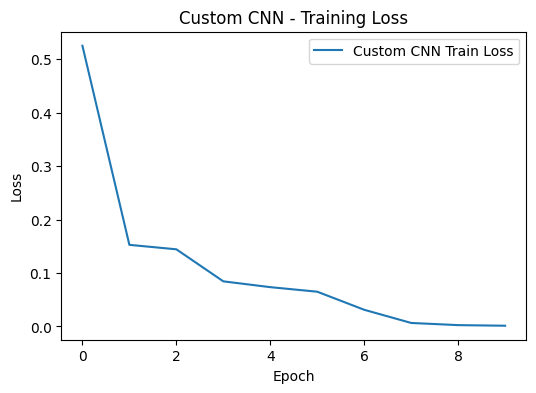

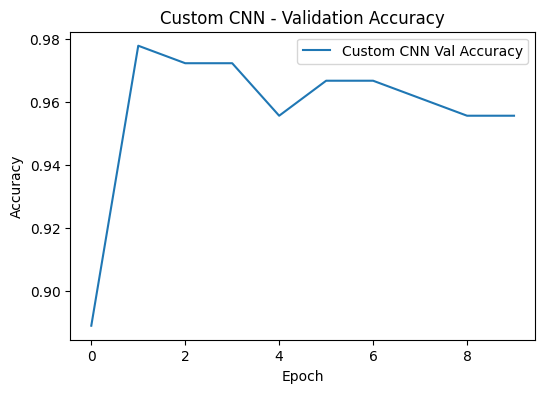

In [58]:
plt.figure(figsize=(6,4))
plt.plot(train_loss, label="Custom CNN Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN - Training Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(val_accuracies, label="Custom CNN Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN - Validation Accuracy")
plt.legend()
plt.show()

In [59]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Custom CNN Classification report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

print("Custom CNN Confusion matrix:")
print(confusion_matrix(all_labels, all_preds))

Custom CNN Classification report:
                              precision    recall  f1-score   support

          free_parking_space       0.93      0.93      0.93        55
      not_free_parking_space       0.97      0.97      0.97       124
partially_free_parking_space       1.00      1.00      1.00         1

                    accuracy                           0.96       180
                   macro avg       0.97      0.97      0.97       180
                weighted avg       0.96      0.96      0.96       180

Custom CNN Confusion matrix:
[[ 51   4   0]
 [  4 120   0]
 [  0   0   1]]
